<a href="https://colab.research.google.com/github/nhanvo2507-bi/BTVN1IC/blob/main/baitap2ICA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 33.5 MB/s eta 0:00:00
Giá tiền đề xuất: 65000.0 VNĐ
Điểm thưởng đề xuất: 60.00000000000003 %


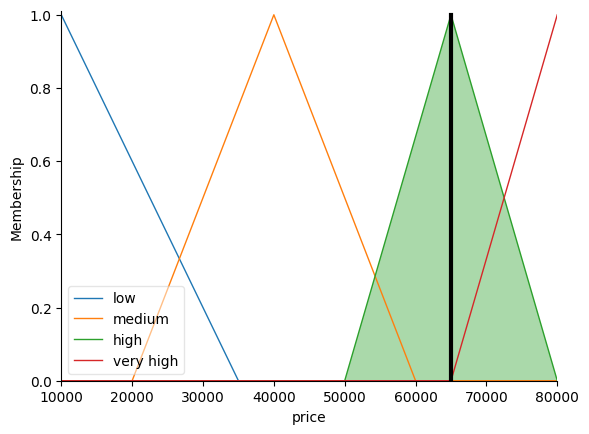

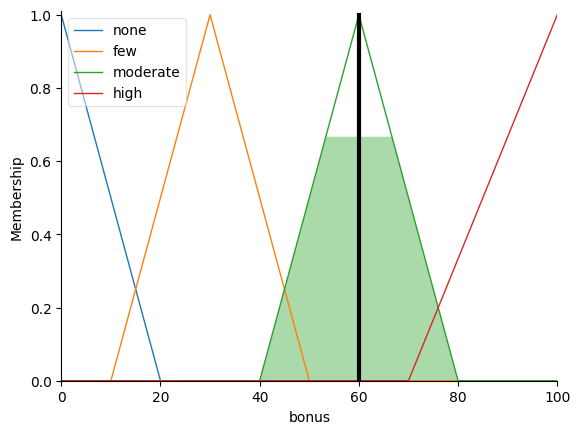

In [1]:
import sys
!{sys.executable} -m pip install scikit-fuzzy
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import numpy as np

# 1. Khai báo biến vào

distance = ctrl.Antecedent(np.arange(0, 50.1, 0.1), 'distance')  # km
traffic = ctrl.Antecedent(np.arange(0, 101, 1), 'traffic')       # %
weather = ctrl.Antecedent(np.arange(0, 2.1, 1), 'weather')       # type of weather
demand = ctrl.Antecedent(np.arange(0, 101, 1), 'demand')
rating = ctrl.Antecedent(np.arange(0, 5.1, 0.1), 'rating')       # sao
punctuality = ctrl.Antecedent(np.arange(0, 101, 1), 'punctuality')  # %

# 2. KKhai báo biến đầu ra

price = ctrl.Consequent(np.arange(10000, 80001, 1000), 'price')  # VNĐ
bonus = ctrl.Consequent(np.arange(0, 101, 1), 'bonus') # % bonus

# 3. Hàm Membership

# Ride Distance
distance['short'] = fuzz.trimf(distance.universe, [0, 0, 3])
distance['medium'] = fuzz.trimf(distance.universe, [2, 5, 8])
distance['long'] = fuzz.trimf(distance.universe, [6, 13, 20])
distance['very long'] = fuzz.trimf(distance.universe, [15, 50, 50])

# Traffic Condition
traffic['low'] = fuzz.trimf(traffic.universe, [0, 0, 30])
traffic['medium'] = fuzz.trimf(traffic.universe, [20, 50, 80])
traffic['high'] = fuzz.trimf(traffic.universe, [60, 100, 100])

# Weather Condition
weather['good'] = fuzz.trimf(weather.universe, [0, 0, 0])
weather['modrate'] = fuzz.trimf(weather.universe, [1, 1, 1])
weather['bad'] = fuzz.trimf(weather.universe, [2, 2, 2])

# Demand Level
demand['low'] = fuzz.trimf(demand.universe, [0, 0, 30])
demand['medium'] = fuzz.trimf(demand.universe, [20, 50, 80])
demand['high'] = fuzz.trimf(demand.universe, [60, 100, 100])

# Customer Rating
rating['poor'] = fuzz.trimf(rating.universe, [1, 1, 2.5])
rating['average'] = fuzz.trimf(rating.universe, [2, 3, 4])
rating['good'] = fuzz.trimf(rating.universe, [3.5, 5, 5])

# Ride Punctuality
punctuality['late'] = fuzz.trimf(punctuality.universe, [0, 0, 50])
punctuality['on time'] = fuzz.trimf(punctuality.universe, [40, 60, 80])
punctuality['early'] = fuzz.trimf(punctuality.universe, [70, 100, 100])

# Price
price['low'] = fuzz.trimf(price.universe, [10000, 10000, 35000])
price['medium'] = fuzz.trimf(price.universe, [20000, 40000, 60000])
price['high'] = fuzz.trimf(price.universe, [50000, 65000, 80000])
price['very high'] = fuzz.trimf(price.universe, [65000, 80000, 80000])

# Bonus
bonus['none'] = fuzz.trimf(bonus.universe, [0, 0, 20])
bonus['few'] = fuzz.trimf(bonus.universe, [10, 30, 50])
bonus['moderate'] = fuzz.trimf(bonus.universe, [40, 60, 80])
bonus['high'] = fuzz.trimf(bonus.universe, [70, 100, 100])

# 4. Luật

rule1  = ctrl.Rule(distance['short']    & traffic['low']      & demand['low'], price['low'])
rule2  = ctrl.Rule(distance['short']    & traffic['medium']   & demand['high'], price['medium'])
rule3  = ctrl.Rule(distance['medium']   & traffic['high']     & demand['high'], price['high'])
rule4  = ctrl.Rule(distance['long']     & traffic['medium']   & weather['good'],  price['medium'])
rule5  = ctrl.Rule(distance['long']     & traffic['high']     & weather['bad'],  price['very high'])
rule6  = ctrl.Rule(distance['very long']  & traffic['high']   & demand['high'], price['very high'])
rule7  = ctrl.Rule(distance['medium']     & traffic['low']    & demand['low'], price['medium'])
rule8  = ctrl.Rule(distance['short']      & traffic['high']   & weather['bad'], price['high'])
rule9  = ctrl.Rule(distance['very long']  & weather['bad'],                     price['high'])
rule10 = ctrl.Rule(distance['medium']     & traffic['medium'] & weather['bad'],  price['high'])
rule11 = ctrl.Rule(rating['good']         & punctuality['early'],               price['low'])

rule12 = ctrl.Rule(rating['average']    & punctuality['on time'], bonus['moderate'])
rule13 = ctrl.Rule(rating['poor']       & punctuality['late'],    bonus['none'])
rule14 = ctrl.Rule(distance['long']     & traffic['high']     & punctuality['on time'], bonus['high'])
rule15 = ctrl.Rule(distance['medium']   & traffic['medium']   & rating['good'],  bonus['moderate'])
rule16 = ctrl.Rule(rating['poor']       & punctuality['late']  ,  bonus['none'])
rule17 = ctrl.Rule(distance['very long']& weather['bad']      & rating['good'],  bonus['high'])
rule18 = ctrl.Rule(distance['short']    & rating['average']   & punctuality['on time'],  bonus['few'])
rule19 = ctrl.Rule(distance['long']     & traffic['high']     & punctuality['late'],  bonus['few'])
rule20 = ctrl.Rule(distance['medium']   & weather['modrate']  & rating['good'],  bonus['moderate'])



# 5. Tạo hệ thống

grab_ctrl = ctrl.ControlSystem([
    rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9, rule10,
    rule11, rule12, rule13, rule14, rule15, rule16, rule17, rule18, rule19, rule20
])

grab = ctrl.ControlSystemSimulation(grab_ctrl)

# 6. Test thử

grab.input['distance'] = 5      # km
grab.input['traffic'] = 50       # %
grab.input['weather'] = 2        # type of weather
grab.input['demand'] = 10        # %
grab.input['rating'] = 4.5       # sao
grab.input['punctuality'] = 10   # %
grab.compute()

print("Giá tiền đề xuất:", grab.output['price'], "VNĐ")
print("Điểm thưởng đề xuất:", grab.output['bonus'], "%")

# Vẽ biểu đồ nếu mún
price.view(sim=grab)
bonus.view(sim=grab)